## 1. Setup

### 1.0 Google Drive Sync

In [1]:
# Adicionar o conteúdo do drive no caminho do sistema

#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

In [2]:
# modificar para o diretorio que contem a pasta do repositorio ao rodar esse notebook
# fazemos isso para ele conseguir ler a pasta /datasets que precisa estar dentro do diretório que contem esse notebook
%cd /content/drive/MyDrive/projetos-if702/projeto-churn/

!dir

[WinError 3] The system cannot find the path specified: '/content/drive/MyDrive/projetos-if702/projeto-churn/'
c:\Users\User\Desktop\Redes neurais\projetos-if702\projeto-churn
 Volume in drive C has no label.
 Volume Serial Number is 92E5-FB3A

 Directory of c:\Users\User\Desktop\Redes neurais\projetos-if702\projeto-churn

06/07/2026  10:07 AM    <DIR>          .
06/07/2026  10:07 AM    <DIR>          ..
06/06/2026  02:37 PM             4,230 0_preprocessamento.ipynb
06/06/2026  02:40 PM            29,454 1_MLP.ipynb
06/04/2026  04:14 PM           395,387 2_XGBoost.ipynb
06/04/2026  04:14 PM             9,732 churn_preprocessing.py
06/05/2026  07:57 PM    <DIR>          datasets
06/06/2026  12:46 PM           233,831 KAN.ipynb
06/06/2026  03:32 PM            27,997 ml_utils.py
06/05/2026  09:53 PM    <DIR>          model
06/06/2026  02:37 PM    <DIR>          models
06/06/2026  02:37 PM    <DIR>          results
06/06/2026  02:37 PM    <DIR>          searches
06/04/2026  02:42 PM      

In [3]:
import sys

# Colocar o caminho exato da pasta onde está a pasta referente ao repositório do projeto
# O caminho base é sempre '/content/drive/MyDrive/' se criar um atalho no "Meu Drive" para a pasta sincronizada
caminho_projeto = '/content/drive/MyDrive/projetos-if702/projeto-churn'

# Adiciona a pasta no path do Python, caso ainda não esteja lá
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

In [4]:

# Fazer recarregamento dos modulos locais.
# Assim não precisa reiniciar o kernel do colab toda vez que modificar alguma coisa nos arquivos .py

import importlib
sys.modules['imp'] = importlib

%load_ext autoreload
%autoreload 2

### 1.1 Importar Libs

In [5]:
# Importação das bibliotecas necessárias
import pandas as pd
import optuna 
import optuna.visualization as optuna_vis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import json
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, loguniform, randint
from joblib import dump, load
import warnings


warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
import torch
from sklearn.model_selection import train_test_split
from scikitplot.metrics import plot_ks_statistic
from joblib import dump, load

from ml_utils import (
    train_model, evaluate_model, ks_test,
    build_hyperparameter_space, print_hyperparameter_space,
    run_optuna_search, get_loss_fn, _preprocess_model_params,
    DEFAULT_SCORING_METRIC, AVAILABLE_METRICS_SEARCH, AVAILABLE_LOSSES,
    RANDOM_STATE_MODEL, RANDOM_STATE_SAMPLE,
)
from churn_preprocessing import load_split_datasets, get_X_y_from_split, OUTPUT_PREFIX, TARGET_COL
try:
    from kan import KAN
except:
    print("❌ KANs não encontrado. Instale com: pip install pykan")

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device.type.upper())

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas importadas com sucesso!
Pandas: 2.3.1
NumPy: 2.3.2
Scikit-learn: 1.7.2
Device: CUDA


### 1.2 Configuração do Modelo

In [6]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "KAN"
MODEL_CLASS = KAN

module_name = getattr(MODEL_CLASS, "__module__", "")
print(f"Modelo configurado: {MODEL_NAME}")
print(module_name)

print("Hiperparâmetros disponíveis na classe do modelo:")
kan_params = [
    "width",
    "grid",
    "k",
    "noise_scale",
    "noise_scale_base",
    "base_fun",
    "symbolic_enabled",
    "bias_trainable",
    "sp_trainable",
    "sb_trainable",
    "lr",
    "batch_size",
    "steps",
    "lamb",
    "lamb_l1",
    "lamb_entropy",
    "lamb_coef",
    "lamb_coefdiff",
    "seed",
]
for param in kan_params:
    print(f"  - {param}")

Modelo configurado: KAN
kan.MultKAN
Hiperparâmetros disponíveis na classe do modelo:
  - width
  - grid
  - k
  - noise_scale
  - noise_scale_base
  - base_fun
  - symbolic_enabled
  - bias_trainable
  - sp_trainable
  - sb_trainable
  - lr
  - batch_size
  - steps
  - lamb
  - lamb_l1
  - lamb_entropy
  - lamb_coef
  - lamb_coefdiff
  - seed


## 2. Carregamento e Preparação dos Dados

In [7]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

train_data, val_data, test_data = load_split_datasets(prefix=OUTPUT_PREFIX)
X_train, y_train, X_val, y_val, X_test, y_test = get_X_y_from_split(train_data, val_data, test_data, TARGET_COL)

X_train_scaled = X_train
X_test_scaled = X_test

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de validação: {val_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", pd.Series(y_train).value_counts().to_dict())
print("Val:", pd.Series(y_val).value_counts().to_dict())
print("Teste:", pd.Series(y_test).value_counts().to_dict())

=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (5174, 20)
Dataset de validação: (2586, 20)
Dataset de teste: (1762, 20)
Features: 19

Distribuição das classes:
Treino: {0: 2587, 1: 2587}
Val: {0: 1293, 1: 1293}
Teste: {0: 1294, 1: 468}


In [8]:
train_data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
0,0.0,-0.181818,0.660499,0.051516,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,0
1,0.0,0.886364,-0.552846,0.591772,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0,2.0,0
2,0.0,0.681818,-0.318475,0.662118,1.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0
3,0.0,-0.363636,0.239978,-0.249371,1.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1
4,1.0,-0.068182,0.086347,0.092913,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1


## 3. Sampling para Busca de Hiperparâmetros

### 3.0 Sampling para busca

In [9]:

SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search
# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train,
    test_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", pd.Series(y_train).value_counts().to_dict())


Dataset original de treino: 5,174 amostras
Amostra para busca de hiperparâmetros: 259 amostras
Redução: 95.0%

Distribuição das classes na amostra:
Amostra: {0: 130, 1: 129}
Original: {0: 2587, 1: 2587}


### 3.1 Configs da Busca Optuna

In [10]:
print("Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra:", DEFAULT_SCORING_METRIC)
print("Métricas disponíveis para a busca de hiperparâmetros:\n", AVAILABLE_METRICS_SEARCH)
print("Funções de perda disponíveis para modelos PyTorch:\n", AVAILABLE_LOSSES)

Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra: ks
Métricas disponíveis para a busca de hiperparâmetros:
 ['accuracy', 'precision', 'recall', 'f1', 'val_loss', 'auroc', 'ks']
Funções de perda disponíveis para modelos PyTorch:
 ['cross_entropy', 'bce_with_logits', 'mse']


In [11]:
# Optuna
n_trials = 100
scoring_metric = 'ks'
loss_fn = get_loss_fn('bce_with_logits')

# modelos PyTorch somente
early_stopping_patience = 10
early_stopping_delta = 0.001
training_epochs_per_trial = 10

### 3.2 Definição do espaço de hiperparâmetros

In [12]:
param_space = build_hyperparameter_space(
    MODEL_CLASS,
    overrides={
        "hidden_dim": {"type": "int", "values": [1, 4]},
        "grid": {"type": "int", "values": [3, 20]},
        "k": {"type": "categorical", "values": [2, 3, 4, 5]},
        "lr": {"type": "float", "values": [1e-4, 1e-1, None, True]},
    },
)

print_hyperparameter_space(param_space)

Hyperparameter space:
- hidden_dim: type=int, args=[1, 4], kwargs={}
- grid: type=int, args=[3, 20], kwargs={}
- k: type=categorical, values=[2, 3, 4, 5]
- lr: type=float, args=[0.0001, 0.1], kwargs={'log': True}


### 3.3 Executar Busca de Hiperparâmetros

In [13]:
print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Trials: {n_trials}")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")
print(f"Hiperparâmetros no espaço: {list(param_space.keys())}")

direction = "minimize" if scoring_metric in {"val_loss", "loss"} else "maximize"

=== BUSCA DE HIPERPARÂMETROS - KAN ===
Iniciando busca de hiperparâmetros para KAN...
Trials: 100
Usando amostra de 259 exemplos

Hiperparâmetros no espaço: ['hidden_dim', 'grid', 'k', 'lr']


In [14]:
study = run_optuna_search(
    model_class=MODEL_CLASS,
    space=param_space,
    X_train=X_sample,
    y_train=y_sample,
    X_val=X_val,
    y_val=y_val,
    n_trials=n_trials,
    direction=direction,
    scoring_metric=scoring_metric,
    device=device,
    epochs=training_epochs_per_trial,
    patience=early_stopping_patience,
    min_delta=early_stopping_delta,
    loss_fn=loss_fn,
)

print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score ({scoring_metric}): {study.best_value:.6f}")

[I 2026-06-07 19:11:51,468] A new study created in memory with name: no-name-cdea6a96-e5fa-4447-bb06-d009e07c0082


checkpoint directory created: ./model
saving model version 0.0


[I 2026-06-07 19:12:09,421] Trial 0 finished with value: 0.09590100541376645 and parameters: {'hidden_dim': 3, 'grid': 17, 'k': 3, 'lr': 0.0001730636667375351}. Best is trial 0 with value: 0.09590100541376645.


checkpoint directory created: ./model
saving model version 0.0


[I 2026-06-07 19:12:16,134] Trial 1 finished with value: 0.202629543696829 and parameters: {'hidden_dim': 1, 'grid': 19, 'k': 4, 'lr': 0.0001946929000633778}. Best is trial 1 with value: 0.202629543696829.


...

checkpoint directory created: ./model
saving model version 0.0


[I 2026-06-07 19:32:55,037] Trial 98 finished with value: 0.5197215777262181 and parameters: {'hidden_dim': 3, 'grid': 9, 'k': 3, 'lr': 0.010891291344470115}. Best is trial 42 with value: 0.522815158546017.


checkpoint directory created: ./model
saving model version 0.0


[I 2026-06-07 19:33:13,219] Trial 99 finished with value: 0.5081206496519721 and parameters: {'hidden_dim': 4, 'grid': 8, 'k': 3, 'lr': 0.010676141744910727}. Best is trial 42 with value: 0.522815158546017.



--- RESULTADOS KAN ---
Melhores hiperparâmetros encontrados:
  hidden_dim: 4
  grid: 6
  k: 5
  lr: 0.018760925184853967

Melhor score (ks): 0.522815


### 3.4 Visualizar histórico da busca

In [15]:
optuna_vis.plot_param_importances(study)

In [16]:
optuna_vis.plot_optimization_history(study, target_name=scoring_metric)

In [17]:
optuna_vis.plot_parallel_coordinate(study, params=list(param_space.keys()), target_name=scoring_metric)

In [18]:
print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS - {MODEL_NAME} ===")

trials_df = study.trials_dataframe()
if "state" in trials_df.columns:
    trials_df = trials_df[trials_df["state"] == "COMPLETE"]
sorted_df = trials_df.sort_values("value", ascending=(direction == "minimize"))

print(f"\nTop configurações (de {len(sorted_df)} trials completos):")
print(sorted_df.head(10).to_string(index=False))

if not sorted_df.empty:
    print(f"\nEstatísticas dos scores encontrados:")
    print(f"  Média: {sorted_df['value'].mean():.4f}")
    print(f"  Mediana: {sorted_df['value'].median():.4f}")
    print(f"  Desvio padrão: {sorted_df['value'].std():.4f}")
    print(f"  Min: {sorted_df['value'].min():.4f}")
    print(f"  Max: {sorted_df['value'].max():.4f}")

=== MELHORES CONFIGURAÇÕES ENCONTRADAS - KAN ===

Top configurações (de 100 trials completos):
 number    value             datetime_start          datetime_complete               duration  params_grid  params_hidden_dim  params_k  params_lr    state
     42 0.522815 2026-06-07 19:20:27.909316 2026-06-07 19:20:44.072993 0 days 00:00:16.163677            6                  4         5   0.018761 COMPLETE
     63 0.519722 2026-06-07 19:25:18.448633 2026-06-07 19:25:31.077987 0 days 00:00:12.629354            8                  3         3   0.009970 COMPLETE
     98 0.519722 2026-06-07 19:32:42.292317 2026-06-07 19:32:55.037496 0 days 00:00:12.745179            9                  3         3   0.010891 COMPLETE
     92 0.518175 2026-06-07 19:31:21.019124 2026-06-07 19:31:34.330243 0 days 00:00:13.311119            8                  3         3   0.009358 COMPLETE
     81 0.517401 2026-06-07 19:29:00.676670 2026-06-07 19:29:15.319137 0 days 00:00:14.642467            8                  3

## 4. Salvar Resultados de Busca

In [19]:
SEARCH_RESULTS_FOLDER = "searches"
os.makedirs(SEARCH_RESULTS_FOLDER, exist_ok=True)

trials_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_trials.csv")
best_params_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_best.json")

In [20]:
trials_df.to_csv(trials_path, index=False)
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=2, default=str)

print("Resultados da busca salvos:")
print(trials_path)
print(best_params_path)

Resultados da busca salvos:
searches\kan_optuna_trials.csv
searches\kan_optuna_best.json


In [21]:
loaded_best_params = None
loaded_trials_df = None

## 5. Carregar Resultado de Busca (Opcional)

In [22]:
if os.path.exists(trials_path):
    loaded_trials_df = pd.read_csv(trials_path)
if os.path.exists(best_params_path):
    with open(best_params_path, "r") as f:
        loaded_best_params = json.load(f)

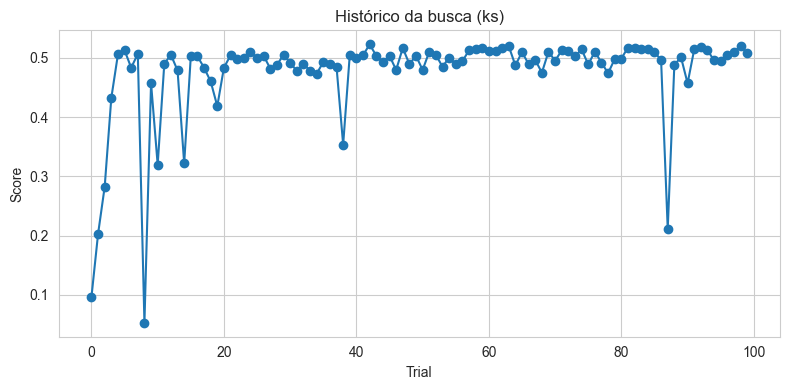

In [23]:
# Plotar a história da busca a partir dos resultados carregados
if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
    plot_df = loaded_trials_df.sort_values("number") if "number" in loaded_trials_df.columns else loaded_trials_df
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["value"].values, marker="o")
    plt.title(f"Histórico da busca ({scoring_metric})")
    plt.xlabel("Trial")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

## 6. Definir Melhores Params e Score de Busca

In [24]:
# Definir Melhores Parâmetros para Uso Posterior
if loaded_best_params is not None:
    best_params = loaded_best_params
    if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
        best_score = (
            loaded_trials_df["value"].min()
            if direction == "minimize"
            else loaded_trials_df["value"].max()
        )
    else:
        best_score = study.best_value
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor score carregado: {best_score:.6f}")
else:
    best_params = study.best_params
    best_score = study.best_value
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor score da busca atual: {best_score:.6f}")

✅ Usando parâmetros carregados: {'hidden_dim': 4, 'grid': 6, 'k': 5, 'lr': 0.018760925184853967}
✅ Melhor score carregado: 0.522815


## 7. Treinar Modelo Final e Salvar

In [25]:
best_params_model = _preprocess_model_params(KAN, best_params.copy(), {}, X_train_scaled)
lr = best_params_model.pop("lr", best_params.get("lr", 1e-3))

best_model = KAN(**best_params_model, seed=RANDOM_STATE_MODEL, device=device)

optimizer = torch.optim.Adam(best_model.parameters(), lr=lr)

best_model.speed()
train_result = train_model(
    model=best_model,
    X_train=X_train_scaled,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
)
best_model = train_result["model"]

checkpoint directory created: ./model
saving model version 0.0


In [26]:
MODELS_FOLDER = "models"
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.pt')
torch.save(best_model.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: models\kan_model.pt


## 8. Avaliação Final e Salvamento dos Resultados

In [27]:
# Carregar modelo (Opcional)
n_features = X_train_scaled.shape[1]
hidden_dim = best_params["hidden_dim"]

loaded_model = KAN(
    width=[n_features, hidden_dim, 1],
    grid=best_params.get("grid", 5),
    k=best_params.get("k", 3),
    grid_range=best_params.get("grid_range", [-2.0, 2.0]),
    seed=RANDOM_STATE_MODEL,
    device=device,
)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.to(device)

checkpoint directory created: ./model
saving model version 0.0


MultKAN(
  (act_fun): ModuleList(
    (0-1): 2 x KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
  (symbolic_fun): ModuleList(
    (0-1): 2 x Symbolic_KANLayer()
  )
)

In [28]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando:", MODEL_NAME)

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train
X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, y_train_pred, y_train_scores = evaluate_model(
    best_model, X_train_eval, y_train_eval, device=device
 )
test_metrics, y_test_pred, y_test_scores = evaluate_model(
    best_model, X_test_eval, y_test_eval, device=device
 )

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - KAN ===

Avaliando: KAN


### 8.1 Classification Report

In [29]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1294
           1       0.52      0.71      0.60       468

    accuracy                           0.75      1762
   macro avg       0.70      0.74      0.71      1762
weighted avg       0.78      0.75      0.76      1762



KS Statistic: 0.5009


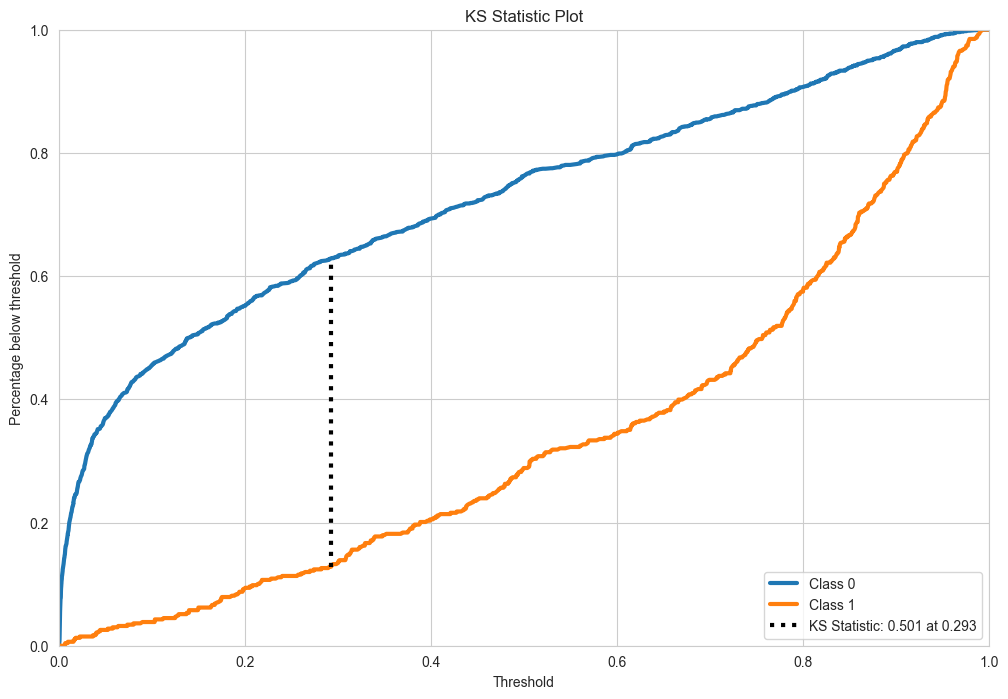

In [30]:
result = ks_test(y_test_eval, y_test_scores)
probas = result["probas"]
print(f"KS Statistic: {result['ks_stat']:.4f}")
ax = plot_ks_statistic(y_test_eval, probas)

### 8.2 Visualize Confusion Matrix

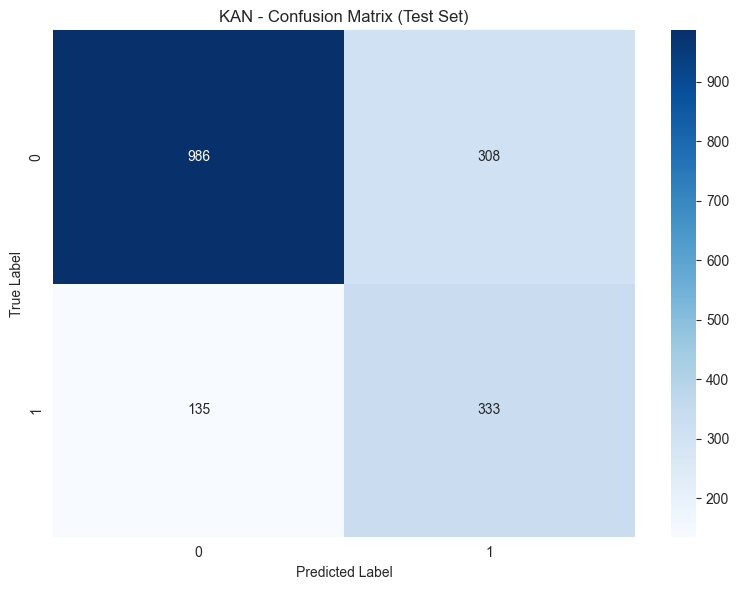

In [31]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [32]:
# Salvar resultados finais
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

final_results = {
    "model_name": MODEL_NAME,
    "best_params": best_params,
    "best_score": best_score,
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
}

final_path = os.path.join(RESULTS_FOLDER, f"{MODEL_NAME.lower()}_final_results.json")
with open(final_path, "w") as f:
    json.dump(final_results, f, indent=2, default=str)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"Score da busca: {best_score:.6f}")
print(f"KS Statistic Teste: {test_metrics['ks_stat']:.4f}")
print(f"AUC-ROC Teste: {test_metrics['auroc']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")


print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"Arquivo final: {final_path}")


--- RESUMO FINAL KAN ---
Score da busca: 0.522815
KS Statistic Teste: 0.5009
AUC-ROC Teste: 0.8249
F1-Score Teste: 0.6005
Acurácia Teste: 0.7486
Precisão Teste: 0.5195
Recall Teste: 0.7115
Resultados salvos em: results/
Arquivo final: results\kan_final_results.json
